# Preliminary

In [1]:
!git clone https://github.com/sht037-lgtm/Q-Vtree.git

Cloning into 'Q-Vtree'...
remote: Enumerating objects: 1272, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 1272 (delta 14), reused 16 (delta 6), pack-reused 1247 (from 1)
Receiving objects: 100% (1272/1272), 37.41 MiB | 41.28 MiB/s, done.
Resolving deltas: 100% (801/801), done.


In [2]:
!pip install -q "transformers==4.49.0" "huggingface_hub>=0.26.0,<1.0" "tokenizers>=0.21.0"
!hf auth login --token "input your hf token"

import transformers
print(transformers.__version__)  # it should print 4.49.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 74.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 100.4 MB/s eta 0:00:00
The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 403, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 401 Client Error: Unauthorized for url: https://huggingface.co/api/whoami-v2

The above excep

In [3]:
# download InternVL3-8B Model
%cd Q-Vtree
from checkpoints.download import download_internvl3

model_path = download_internvl3()
print("InternVL3-8B ready at:", model_path)

/kaggle/working/Q-Vtree
[INFO] Downloading OpenGVLab/InternVL3-8B ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Fetching 24 files:   0%|          | 0/24 [00:00<?, ?it/s]

conversation.py: 0.00B [00:00, ?B/s]

configuration_intern_vit.py: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

[INFO] Download complete: /kaggle/working/Q-Vtree/checkpoints/InternVL3-8B
Model path: /kaggle/working/Q-Vtree/checkpoints/InternVL3-8B
InternVL3-8B ready at: /kaggle/working/Q-Vtree/checkpoints/InternVL3-8B


In [4]:
import torch
from transformers import AutoTokenizer, AutoModel
from InternVL.model import InternVLChatModelWithTree

model_path = "checkpoints/InternVL3-8B"

tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
model_tree = InternVLChatModelWithTree.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
).eval()

print("Model class:", model_tree.__class__.__name__)
print("Tree model loaded:", model_path)

2026-04-07 07:13:53.637849: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775546033.850630      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775546033.920790      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775546034.432201      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775546034.432236      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775546034.432239      55 computation_placer.cc:177] computation placer alr

FlashAttention2 is not installed.


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model class: InternVLChatModelWithTree
Tree model loaded: checkpoints/InternVL3-8B


In [ ]:
# load general InternVL3-8B
import torch
from transformers import AutoTokenizer, AutoModel

model_path = "checkpoints/InternVL3-8B"

tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
model = AutoModel.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
).eval()

print("Model class:", model.__class__.__name__)
print("Model loaded:", model_path)

# Demo

In [5]:
!ls img

demo_10_heatmap.jpg   demo_2_selected.png  demo_5_selected.png
demo_10.jpeg	      demo_3_heatmap.png   demo_6.jpeg
demo_10_selected.jpg  demo_3.jpeg	   demo_7.jpeg
demo_11.jpeg	      demo_4_heatmap.jpg   demo_8.jpeg
demo_12.jpeg	      demo_4.jpeg	   demo_9_heatmap.jpg
demo_1.jpg	      demo_4_selected.jpg  demo_9.jpeg
demo_2_heatmap.png    demo_5_heatmap.png   demo_9_selected.jpg
demo_2.jpeg	      demo_5.jpeg


In [6]:
image_path = "img/demo_12.jpeg"
question = "What's the breed of this dog?"

response = model_tree.infer(
    tokenizer=tokenizer,
    image_path=image_path,
    question=question,
)
print("Response:", response)

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Response: The dog in the image appears to be a Bulldog, possibly an American Bulldog or a French Bulldog. Both breeds have stocky builds and distinctive facial features, such as a short snout and a wrinkled face.


In [7]:
ratio_w, ratio_h = model_tree._debug_best_ratio
num_main = ratio_w * ratio_h

print(f"best_ratio: {model_tree._debug_best_ratio}  num_tiles: {len(model_tree._debug_patch_ids)}")
print(f"{'Tile':<6} {'Selected':>10} {'Total':>8} {'Ratio':>8}")
print("-" * 36)
for i in range(len(model_tree._debug_patch_ids)):
    tag = "(thumb)" if i == num_main else ""
    print(f"{i:<6} {model_tree._debug_num_selected_tokens[i]:>10} "
          f"{model_tree._debug_num_total_tokens[i]:>8} "
          f"{model_tree._debug_select_ratios[i]:>8.1%} {tag}")

avg = sum(model_tree._debug_select_ratios[:num_main]) / num_main
print(f"\navg select ratio (content tiles): {avg:.1%}")

best_ratio: (3, 2)  num_tiles: 7
Tile     Selected    Total    Ratio
------------------------------------
0              24      256     9.4% 
1              68      256    26.6% 
2              80      256    31.2% 
3              52      256    20.3% 
4              40      256    15.6% 
5              56      256    21.9% 
6              17      256     6.6% (thumb)

avg select ratio (content tiles): 20.8%


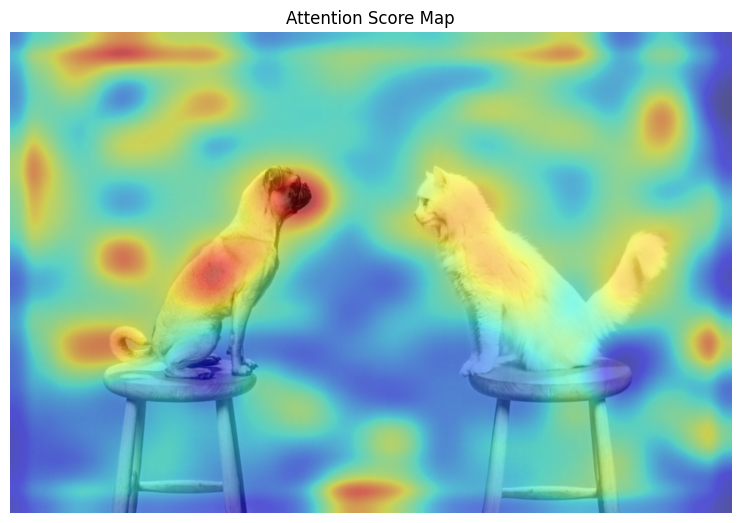

In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from PIL import Image

ratio_w, ratio_h = model_tree._debug_best_ratio
num_main   = ratio_w * ratio_h
grid_hw    = int(model_tree.num_image_token ** 0.5)
input_size = 448
full_w     = ratio_w * input_size
full_h     = ratio_h * input_size
alpha      = 0.5

smoothed = model_tree._debug_patch_scores
rows = []
for row in range(ratio_h):
    cols = [smoothed[row * ratio_w + col].float().view(grid_hw, grid_hw) for col in range(ratio_w)]
    rows.append(torch.cat(cols, dim=1))
full_map = torch.cat(rows, dim=0).numpy()
full_map = (full_map - full_map.min()) / (full_map.max() - full_map.min() + 1e-6)

img     = Image.open(image_path).convert("RGB").resize((full_w, full_h))
img_arr = np.array(img)

score_arr = np.array(
    Image.fromarray((full_map * 255).astype(np.uint8)).resize((full_w, full_h), Image.BICUBIC)
) / 255.0

heatmap = (cm.jet(score_arr)[:, :, :3] * 255).astype(np.uint8)
blended = (img_arr * (1 - alpha) + heatmap * alpha).astype(np.uint8)

plt.figure(figsize=(8, 8 * full_h / full_w))
plt.imshow(blended)
plt.axis("off")
plt.title(f"Attention Score Map")
plt.tight_layout()
plt.savefig(f"{image_path}_scoremap.png", dpi=150, bbox_inches="tight")
plt.show()

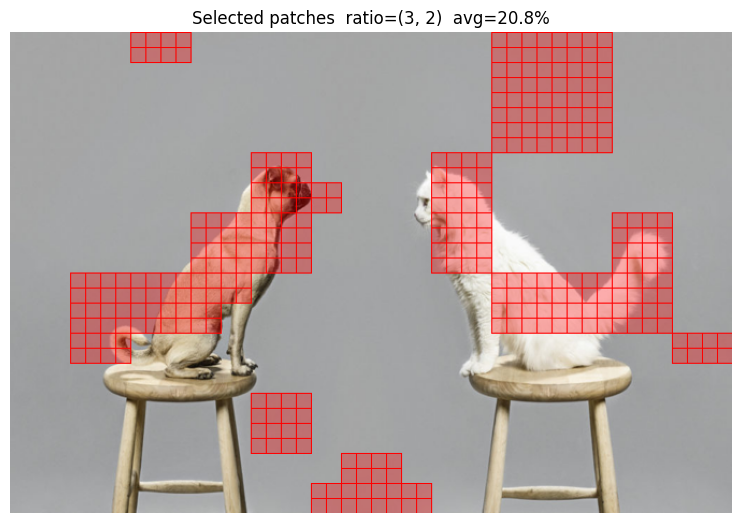

In [9]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

ratio_w, ratio_h = model_tree._debug_best_ratio
num_main   = ratio_w * ratio_h
grid_hw    = int(model_tree.num_image_token ** 0.5)
patch_size = 14
tile_px    = grid_hw * patch_size
full_w     = ratio_w * tile_px
full_h     = ratio_h * tile_px

img     = Image.open(image_path).convert("RGB").resize((full_w, full_h))
overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
draw    = ImageDraw.Draw(overlay)

for tile_idx in range(num_main):
    patch_ids = model_tree._debug_patch_ids[tile_idx]
    tile_col  = tile_idx % ratio_w
    tile_row  = tile_idx // ratio_w
    ox = tile_col * tile_px
    oy = tile_row * tile_px
    for idx in patch_ids.tolist():
        r = idx // grid_hw
        c = idx % grid_hw
        draw.rectangle(
            [ox + c * patch_size,       oy + r * patch_size,
             ox + (c + 1) * patch_size, oy + (r + 1) * patch_size],
            fill=(255, 0, 0, 80), outline=(255, 0, 0, 255),
        )

out = Image.alpha_composite(img.convert("RGBA"), overlay)
avg = sum(model_tree._debug_select_ratios[:num_main]) / num_main

plt.figure(figsize=(8, 8 * full_h / full_w))
plt.imshow(out)
plt.axis("off")
plt.title(f"Selected patches  ratio={model_tree._debug_best_ratio}  avg={avg:.1%}")
plt.tight_layout()
plt.savefig(f"{image_path}_selected.png", dpi=150, bbox_inches="tight")
plt.show()

# Crop Version

In [15]:
from qwen.crop_infer import CropInferenceWrapper

infer = CropInferenceWrapper(
    tree_model=tree_model,
    base_model=base_model,
    processor=processor,
)

out = infer(
    image_path=demo_img,
    question = "What breed is the dog in the image?\n\n"
)

print(out)

ModuleNotFoundError: No module named 'qwen.crop_infer'

# Evaluation

In [7]:
# download evaluation datasets (vstar,hrbench)
%cd datasets
!python download.py
!ls
%cd ..

from qwen.evaluate import (
    run_vstar_inference,
    evaluate_vstar_predictions,
    run_hrbench_inference,
    evaluate_hrbench_predictions,
)

/kaggle/working/Q-Vtree/datasets
[INFO] Downloading VStar dataset from: craigwu/vstar_bench
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:190: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
Fetching 478 files: 100%|█████████████████████| 478/478 [00:13<00:00, 35.67it/s]
Download complete: : 380MB [00:13, 21.5MB/s]                                    [INFO] VStar download complete.
[INFO] Downloading HR-Bench from: DreamMr/HR-Bench


Fetching 7 files:   0%|                                   | 0/7 [00:00<?, ?it/s]

Fetching 7 files:  14%|███▊                       | 1/7 [00:00<00:00,  9.42it/s]

Fetching 7 files:  43%|███████████▌               | 3/7 [00:00<00:00, 15.34it/s]

Fetching 7 files:  71%|███████████████████▎       | 5/7 [00:05<00:02,  1.29s/it]
Download complete: : 380MB [00:30, 21.5MB/s]| 8.64G/9.82G [00:16<00:03, 324MB/s]

Fetching 7 files:

In [ ]:
# base qwen + vstar
pred_file = run_vstar_inference(
    model=base_model,
    processor=processor,
    model_type="base_qwen",
    run_name="base_qwen_vstar",
    max_samples=10,
)
evaluate_vstar_predictions(pred_file)

Running V-Star inference [base_qwen]:  10%|█         | 1/10 [00:04<00:37,  4.16s/it]

[ERROR][base_qwen] question_id=0: CUDA out of memory. Tried to allocate 14.02 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.70 GiB is free. Including non-PyTorch memory, this process has 7.86 GiB memory in use. Of the allocated memory 7.72 GiB is allocated by PyTorch, and 15.14 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Running V-Star inference [base_qwen]:  20%|██        | 2/10 [00:07<00:29,  3.72s/it]

[ERROR][base_qwen] question_id=1: CUDA out of memory. Tried to allocate 17.80 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.42 GiB is free. Including non-PyTorch memory, this process has 8.14 GiB memory in use. Of the allocated memory 7.81 GiB is allocated by PyTorch, and 212.48 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Running V-Star inference [base_qwen]:  30%|███       | 3/10 [00:10<00:24,  3.55s/it]

...

[ERROR][base_qwen] question_id=3: CUDA out of memory. Tried to allocate 17.80 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.44 GiB is free. Including non-PyTorch memory, this process has 8.12 GiB memory in use. Of the allocated memory 7.81 GiB is allocated by PyTorch, and 183.91 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Running V-Star inference [base_qwen]:  50%|█████     | 5/10 [00:17<00:17,  3.47s/it]

[ERROR][base_qwen] question_id=4: CUDA out of memory. Tried to allocate 17.80 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.44 GiB is free. Including non-PyTorch memory, this process has 8.12 GiB memory in use. Of the allocated memory 7.81 GiB is allocated by PyTorch, and 183.90 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Running V-Star inference [base_qwen]:  60%|██████    | 6/10 [00:21<00:13,  3.45s/it]

[ERROR][base_qwen] question_id=5: CUDA out of memory. Tried to allocate 17.80 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.44 GiB is free. Including non-PyTorch memory, this process has 8.12 GiB memory in use. Of the allocated memory 7.81 GiB is allocated by PyTorch, and 183.91 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


In [15]:
# tree qwen + vstar
pred_file = run_vstar_inference(
    model=tree_model,
    processor=processor,
    model_type="tree_qwen",
    run_name="tree_qwen_vstar",
    max_samples=10,
)
evaluate_vstar_predictions(pred_file)

[DEBUG] model class = Qwen2_5_VLForConditionalGenerationWithTree


Running V-Star inference [tree_qwen]:  10%|█         | 1/10 [00:03<00:30,  3.38s/it]

[ERROR][tree_qwen] question_id=0: CUDA out of memory. Tried to allocate 14.02 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.24 GiB is free. Including non-PyTorch memory, this process has 8.32 GiB memory in use. Of the allocated memory 7.73 GiB is allocated by PyTorch, and 474.95 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Running V-Star inference [tree_qwen]:  20%|██        | 2/10 [00:06<00:27,  3.40s/it]

[ERROR][tree_qwen] question_id=1: CUDA out of memory. Tried to allocate 17.80 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.24 GiB is free. Including non-PyTorch memory, this process has 8.32 GiB memory in use. Of the allocated memory 7.83 GiB is allocated by PyTorch, and 377.05 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


...

Running V-Star inference [tree_qwen]:  90%|█████████ | 9/10 [00:30<00:03,  3.43s/it]

[ERROR][tree_qwen] question_id=8: CUDA out of memory. Tried to allocate 22.03 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.24 GiB is free. Including non-PyTorch memory, this process has 8.32 GiB memory in use. Of the allocated memory 7.92 GiB is allocated by PyTorch, and 280.38 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Running V-Star inference [tree_qwen]: 100%|██████████| 10/10 [00:33<00:00,  3.38s/it]

[ERROR][tree_qwen] question_id=9: CUDA out of memory. Tried to allocate 17.80 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.24 GiB is free. Including non-PyTorch memory, this process has 8.32 GiB memory in use. Of the allocated memory 7.83 GiB is allocated by PyTorch, and 377.05 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
[INFO] Saved predictions to: datasets/vstar_bench/vstar_predictions_tree_qwen_vstar.jsonl
Accuracy: 0.0000 (0/10)


0.0

In [ ]:
from qwen.crop_infer import CropInferenceWrapper
from qwen.evaluate import run_vstar_with_crop

# crop + vstar
infer = CropInferenceWrapper(
    tree_model=tree_model,
    base_model=base_model,
    processor=processor,
)

run_vstar_with_crop(
    infer,
    dataset_dir="datasets/vstar_bench",
    max_samples=10
)

V-Star + Crop:  10%|█         | 1/10 [00:04<00:38,  4.25s/it]

[ERROR] 0: CUDA out of memory. Tried to allocate 14.02 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.70 GiB is free. Including non-PyTorch memory, this process has 7.86 GiB memory in use. Of the allocated memory 7.72 GiB is allocated by PyTorch, and 15.14 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


V-Star + Crop:  20%|██        | 2/10 [00:07<00:30,  3.86s/it]

[ERROR] 1: CUDA out of memory. Tried to allocate 17.80 GiB. GPU 0 has a total capacity of 14.56 GiB of which 6.42 GiB is free. Including non-PyTorch memory, this process has 8.14 GiB memory in use. Of the allocated memory 7.81 GiB is allocated by PyTorch, and 212.48 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


In [29]:
# base qwen + hrbench 4k
pred_file = run_hrbench_inference(
    model=base_model,
    processor=processor,
    split="4k",
    model_type="base_qwen",
    run_name="base_qwen_hrbench4k",
    max_samples=10,
)
evaluate_hrbench_predictions(pred_file)

Running HR-Bench 4k [base_qwen]:  10%|█         | 1/10 [00:01<00:12,  1.37s/it]

[ERROR][base_qwen] index=0: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running HR-Bench 4k [base_qwen]:  20%|██        | 2/10 [00:02<00:10,  1.27s/it]

[ERROR][base_qwen] index=1: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running HR-Bench 4k [base_qwen]:  30%|███       | 3/10 [00:03<00:08,  1.24s/it]

...

Running HR-Bench 4k [base_qwen]:  90%|█████████ | 9/10 [00:11<00:01,  1.21s/it]

[ERROR][base_qwen] index=8: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



Running HR-Bench 4k [base_qwen]: 100%|██████████| 10/10 [00:12<00:00,  1.23s/it]

[ERROR][base_qwen] index=9: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.

[INFO] Saved predictions to: datasets/hr_bench/hr_bench_4k_predictions_base_qwen_hrbench4k.jsonl
Accuracy: 0.0000 (0/10)


0.0

In [ ]:
# tree qwen + hrbench 4k
pred_file = run_hrbench_inference(
    model=tree_model,
    processor=processor,
    split="4k",
    model_type="tree_qwen",
    run_name="tree_qwen_hrbench4k",
    max_samples=10,
)
evaluate_hrbench_predictions(pred_file)

In [ ]:
# base qwen + hrbench 8k
pred_file = run_hrbench_inference(
    model=base_model,
    processor=processor,
    split="8k",
    model_type="base_qwen",
    run_name="base_qwen_hrbench8k",
    max_samples=10,
)
evaluate_hrbench_predictions(pred_file)

In [ ]:
# tree qwen + hrbench 8k
pred_file = run_hrbench_inference(
    model=tree_model,
    processor=processor,
    split="8k",
    model_type="tree_qwen",
    run_name="tree_qwen_hrbench8k",
    max_samples=10,
)
evaluate_hrbench_predictions(pred_file)